In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = (224,224)
BATCH_SIZE = 32
DATA_PATH = "/kaggle/input/datasets/sanjeethpekumar/facemask/data"


2026-03-24 16:19:38.428865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774369178.812736      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774369178.912449      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774369179.807021      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774369179.807058      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774369179.807062      55 computation_placer.cc:177] computation placer alr

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=20,           
    zoom_range=0.2,              
    shear_range=0.2,             
    horizontal_flip=True,        
    validation_split=0.2         
)

In [4]:
train_data = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

Found 6043 images belonging to 2 classes.


In [5]:
val_data = train_datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 1510 images belonging to 2 classes.


In [6]:
print("Class Indices:", train_data.class_indices)

Class Indices: {'with_mask': 0, 'without_mask': 1}


In [7]:
images, labels = next(train_data)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


In [8]:
# Class imbalance check:
import numpy as np

labels = train_data.classes
print(np.bincount(labels))

[2980 3063]


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [10]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers:
    layer.trainable = False

I0000 00:00:1774371152.129285      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774371152.135950      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

In [12]:
model = models.Model(inputs=base_model.input, outputs=output)

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
print(len(model.layers))

159


In [15]:
for layer in model.layers[:5]:
    print(layer.trainable)

False
False
False
False
False


In [16]:
# The input layer is automatically created when defining the input shape in MobileNetV2. It accepts images of size 224x224x3

In [19]:
 from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [20]:
# CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [21]:
# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
# TRAIN MODEL
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1774372183.937079     167 service.cc:152] XLA service 0x78a004111940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774372183.937135     167 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774372183.937141     167 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774372185.417461     167 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-24 17:09:55.698318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-24 17:09:55.835999: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1774372198.129214     167 device_co

 92/189 ━━━━━━━━━━━━━━━━━━━━ 44s 464ms/step - accuracy: 0.9177 - loss: 0.1995

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...


Epoch 1: val_accuracy improved from -inf to 0.98477, saving model to best_model.h5


189/189 ━━━━━━━━━━━━━━━━━━━━ 155s 711ms/step - accuracy: 0.9394 - loss: 0.1513 - val_accuracy: 0.9848 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9832 - loss: 0.0460
Epoch 2: val_accuracy improved from 0.98477 to 0.98609, saving model to best_model.h5


189/189 ━━━━━━━━━━━━━━━━━━━━ 84s 444ms/step - accuracy: 0.9832 - loss: 0.0460 - val_accuracy: 0.9861 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9841 - loss: 0.0474
Epoch 3: val_accuracy improved from 0.98609 to 0.99007, saving model to best_model.h5


189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 440ms/step - accuracy: 0.9841 - loss: 0.0474 - val_accuracy: 0.9901 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9849 - loss: 0.0488
Epoch 4: val_accuracy did not improve from 0.99007
189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 438ms/step - accuracy: 0.9849 - loss: 0.0488 - val_accuracy: 0.9854 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9877 - loss: 0.0421
Epoch 5: val_accuracy did not improve from 0.99007
189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 435ms/step - accuracy: 0.9877 - loss: 0.0420 - val_accuracy: 0.9868 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9928 - loss: 0.0224
Epoch 6: val_accuracy did not improve from 0.99007
189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 436ms/step - accuracy: 0.9928 - loss: 0.0224 - val_accuracy: 0.9887 - val_loss: 0.0388 - learning_rate: 3.0000e-04
Epo

189/189 ━━━━━━━━━━━━━━━━━━━━ 82s 436ms/step - accuracy: 0.9928 - loss: 0.0210 - val_accuracy: 0.9921 - val_loss: 0.0403 - learning_rate: 3.0000e-04
Epoch 9/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9925 - loss: 0.0229
Epoch 9: val_accuracy did not improve from 0.99205
189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 438ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.9894 - val_loss: 0.0446 - learning_rate: 9.0000e-05


In [23]:
model.evaluate(val_data)

48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 340ms/step - accuracy: 0.9845 - loss: 0.0442


[0.04724472761154175, 0.9854304790496826]

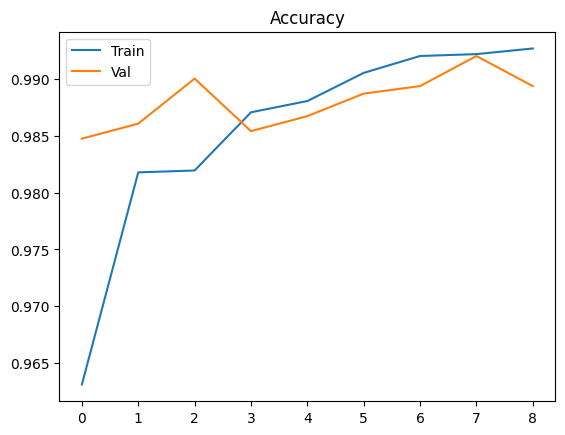

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Val'])
plt.title("Accuracy")
plt.show()

In [25]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [26]:

from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 112s 517ms/step - accuracy: 0.9626 - loss: 0.1042 - val_accuracy: 0.9868 - val_loss: 0.0885
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 440ms/step - accuracy: 0.9785 - loss: 0.0588 - val_accuracy: 0.9901 - val_loss: 0.0746
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 84s 445ms/step - accuracy: 0.9835 - loss: 0.0450 - val_accuracy: 0.9828 - val_loss: 0.0800
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 439ms/step - accuracy: 0.9813 - loss: 0.0542 - val_accuracy: 0.9921 - val_loss: 0.0453
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 84s 446ms/step - accuracy: 0.9858 - loss: 0.0386 - val_accuracy: 0.9914 - val_loss: 0.0367


In [28]:
#Fine-tuning improved feature adaptation while maintaining strong generalization, with peak validation accuracy around 99.2%

In [29]:
# Real-Time Face Mask Detection
# Webcam → Face Detection → Mask Prediction → Display

In [31]:
#I used ModelCheckpoint to save the best model based on validation accuracy instead of relying on the final epoch.